In [1]:
# We connect Google Colab to Google Drive, to ensure your notebook (the .ipynb file) is saved and accessible at any time for future use or download
from google.colab import drive
drive.mount('/content/gdrive')
# You can create the folder directly in Colab using the command below; you can change the folder -  ex.: '/content/gdrive/MyDrive/Project_1'
!mkdir -p '/content/gdrive/MyDrive/TF_Project'
print("Folder created successfully")

Mounted at /content/gdrive
Folder created successfully


In [2]:
# Add the path for the Python code for your project folder
import sys
sys.path.append('/content/gdrive/MyDrive/TF_Project')

In [3]:
# Connect the Matplotlib library to visualize images in the model from the your folder
from IPython.display import Image
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans']
matplotlib.rcParams['text.usetex'] = False

In [4]:
import tensorflow as tf
print(tf.test.is_built_with_cuda())
GPU=tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(GPU))
if GPU:
    try:
        for gpu in GPU:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPU.")
    except RuntimeError as e:
        print(e)
h = tf.constant("Hello")
w = tf.constant(" World!")
hw = h+w
print(hw.numpy().decode("utf-8"))

True
Num GPUs Available:  1
Memory growth set for GPU.
Hello World!


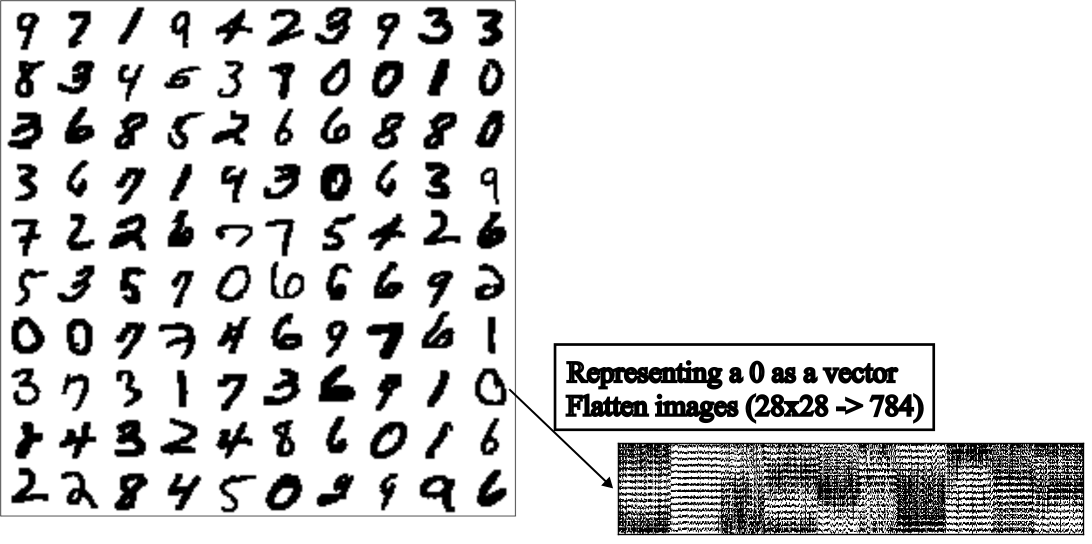

In [5]:
# Configure the path if needed, mainly due to the name of your folder: /content/gdrive/MyDrive/name_folder/MNIST.png
Image('/content/gdrive/MyDrive/TF_Project/MNIST.png', width=700)

In [6]:
%pip install "pandas>=2.0,<3.0" meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 42.4 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


Temperature : (43824,) → [5.  4.6 4.4]
Humidity    : (43824,) → [90 93 94]
Pressure    : (43824,) → [1006.4 1006.6 1007.1]
Precipitation: (43824,) → [nan 0.4 1. ]
Snow        : None
Wind speed  : (43824,)
Weather code: (43824,)


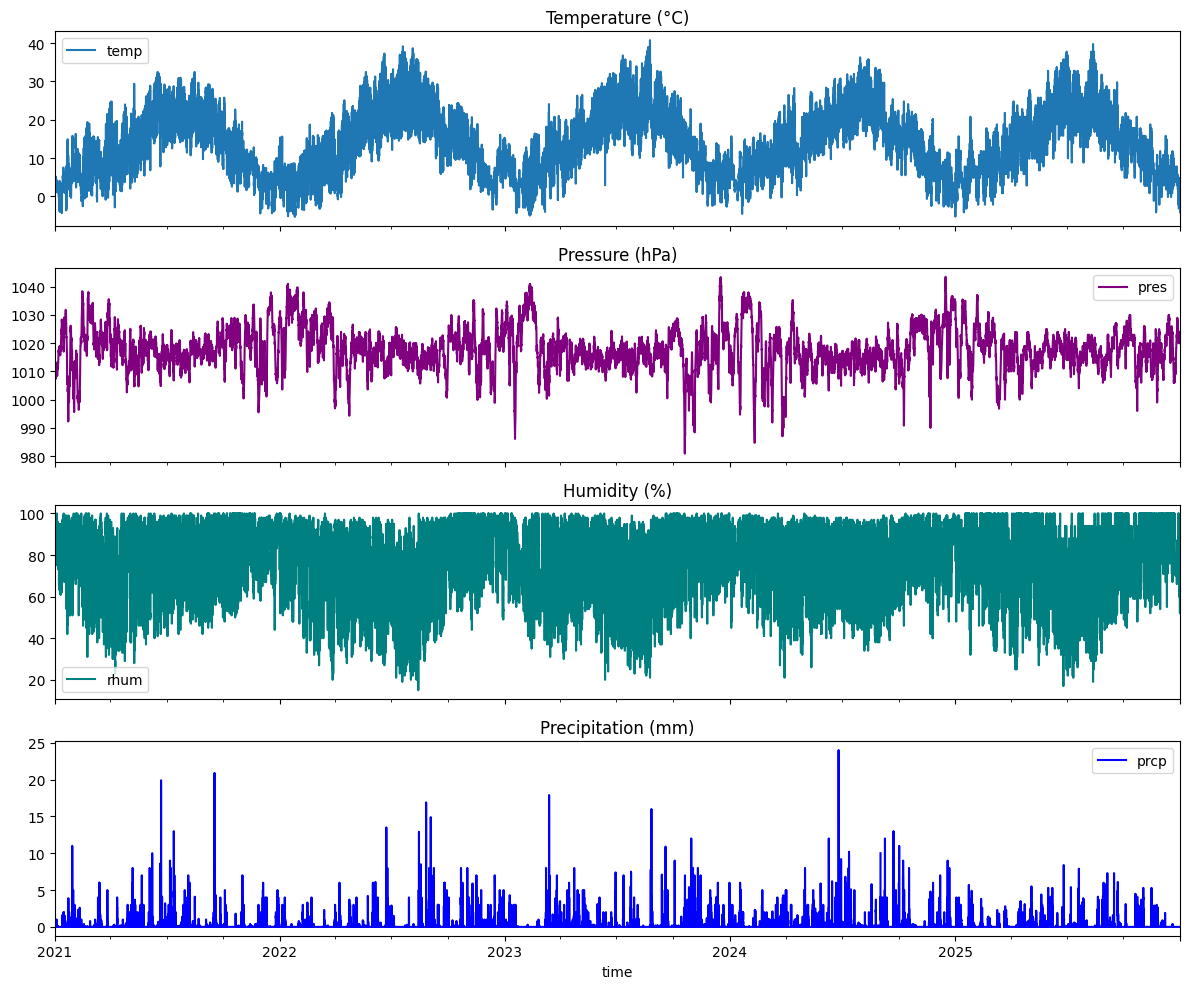

In [8]:
from datetime import date
import matplotlib.pyplot as plt
import meteostat as ms

# In cases of ranges > 3 years, Meteostat blocks hourly requests by default.
# Disable this guard for your long-range test (use responsibly).
ms.config.block_large_requests = False

# Specify location and time range
POINT = ms.Point(45.641632, 5.869613, 113)  # Try with your location
START = date(2021, 1, 1)
END = date(2025, 12, 31)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

# Get hourly data & perform interpolation
ts = ms.hourly(stations, START, END)
df = ms.interpolate(ts, POINT).fetch()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

df.plot(ax=axes[0], y=[ms.Parameter.TEMP], title="Temperature (°C)")
df.plot(ax=axes[1], y=[ms.Parameter.PRES], title="Pressure (hPa)", color="purple")
df.plot(ax=axes[2], y=[ms.Parameter.RHUM], title="Humidity (%)", color="teal")
df.plot(ax=axes[3], y=[ms.Parameter.PRCP], title="Precipitation (mm)", color="blue")

# Extract each parameter into its own array
temp   = df[ms.Parameter.TEMP].to_numpy()
tmin   = df[ms.Parameter.TMIN].to_numpy() if ms.Parameter.TMIN in df.columns else None
tmax   = df[ms.Parameter.TMAX].to_numpy() if ms.Parameter.TMAX in df.columns else None
pres   = df[ms.Parameter.PRES].to_numpy()
rhum   = df[ms.Parameter.RHUM].to_numpy()
prcp   = df[ms.Parameter.PRCP].to_numpy()
snow   = df[ms.Parameter.SNOW].to_numpy() if ms.Parameter.SNOW in df.columns else None
wspd   = df[ms.Parameter.WSPD].to_numpy() if ms.Parameter.WSPD in df.columns else None
coco   = df[ms.Parameter.COCO].to_numpy() if ms.Parameter.COCO in df.columns else None

# The date index can also be saved as an array
dates  = df.index.to_numpy()

print(f"Temperature : {temp.shape} → {temp[:3]}")
print(f"Humidity    : {rhum.shape} → {rhum[:3]}")
print(f"Pressure    : {pres.shape} → {pres[:3]}")
print(f"Precipitation: {prcp.shape} → {prcp[:3]}")
print(f"Snow        : {None if snow is None else snow.shape}")
print(f"Wind speed  : {None if wspd is None else wspd.shape}")
print(f"Weather code: {None if coco is None else coco.shape}")

plt.tight_layout()
plt.show()

Exports enregistrés dans: /content/gdrive/MyDrive/TF_Project
Dataset size   : 43824 échantillons
Nb de classes  : 13
Entrées STM32  : pression, température, humidité (+ historique t-1)
Répartition des classes:
  - Clair / ensoleillé              : 1557
  - Peu nuageux                     : 5885
  - Partiellement nuageux           : 5390
  - Nuageux / couvert               : 21690
  - Pluie                           : 3099
  - Averses                         : 3471
  - Neige légère / averses de neige : 146
  - Pluie et neige mêlées           : 7
  - Orage                           : 44
  - Brouillard / brume              : 2354
  - Vent fort                       : 79
  - Orage violent                   : 102
Class weights: {0: 1.4713286479250334, 1: 0.9, 2: 0.9, 3: 0.9, 4: 1.062486553717897, 5: 1.018222602328652, 7: 1.6, 8: 1.6, 9: 1.6, 10: 1.193045229244114, 11: 1.6, 12: 1.6, 6: 1.0}


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,245 (387.68 KB)

 Trainable params: 97,773 (381.93 KB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4351 - loss: 1.9206 - top3_accuracy: 0.7046
Epoch 1: val_accuracy improved from None to 0.49994, saving model to /content/gdrive/MyDrive/TF_Project/best_top1_model.keras

Epoch 1: finished saving model to /content/gdrive/MyDrive/TF_Project/best_top1_model.keras
366/366 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.5059 - loss: 1.6586 - top3_accuracy: 0.8042 - val_accuracy: 0.4999 - val_loss: 1.6431 - val_top3_accuracy: 0.8075 - learning_rate: 5.0000e-04
Epoch 2/100
359/366 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5482 - loss: 1.3788 - top3_accuracy: 0.8870
Epoch 2: val_accuracy improved from 0.49994 to 0.57182, saving model to /content/gdrive/MyDrive/TF_Project/best_top1_model.keras

Epoch 2: finished saving model to /content/gdrive/MyDrive/TF_Project/best_top1_model.keras
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5559 - loss: 1.3219 - top3_accuracy: 0.8929 - val_accuracy: 0.5718 - val_loss: 1.222

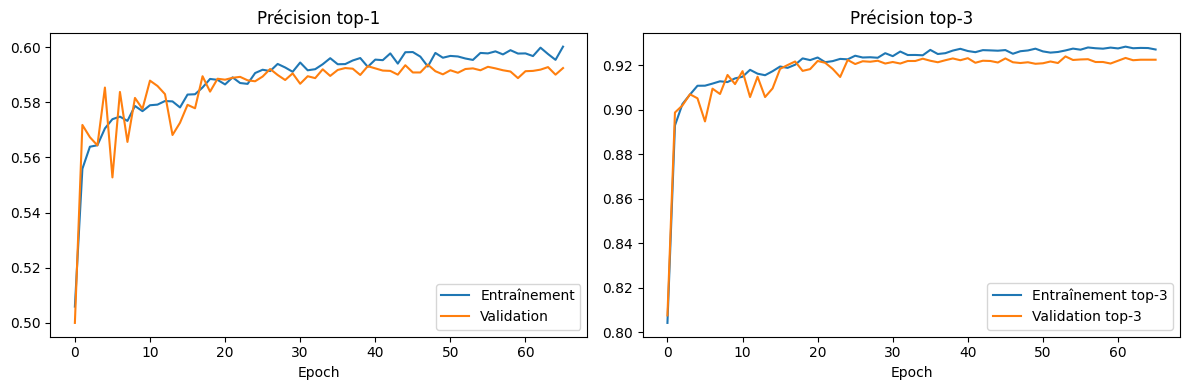

In [19]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Dossier Google Drive où enregistrer tous les artefacts du modèle
PROJECT_DIR = "/content/gdrive/MyDrive/TF_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Exports enregistrés dans: {PROJECT_DIR}")

# ── 1. Define French classes (from your weather taxonomy) ────────────────────
CLASSES_FR = [
    "Clair / ensoleillé",
    "Peu nuageux",
    "Partiellement nuageux",
    "Nuageux / couvert",
    "Pluie",
    "Averses",
    "Neige",
    "Neige légère / averses de neige",
    "Pluie et neige mêlées",
    "Orage",
    "Brouillard / brume",
    "Vent fort",
    "Orage violent",
]

# Meteostat COCO -> class index mapping (used to build labels from historical data)
def map_coco_to_class(coco_value, prcp_value, snow_value, wspd_value):
    c = int(coco_value) if np.isfinite(coco_value) else -1
    p = 0.0 if not np.isfinite(prcp_value) else float(prcp_value)
    s = 0.0 if not np.isfinite(snow_value) else float(snow_value)
    w = 0.0 if not np.isfinite(wspd_value) else float(wspd_value)

    if w >= 35.0:
        return 11  # Vent fort
    if c in (1,):
        return 0  # Clair
    if c in (2,):
        return 1  # Peu nuageux
    if c in (3,):
        return 2  # Partiellement nuageux
    if c in (4,):
        return 3  # Nuageux
    if c in (5, 6):
        return 10  # Brouillard / brume
    if c in (7, 8, 9):
        return 4 if p >= 0.5 else 5  # Pluie / Averses
    if c in (10, 11):
        return 8  # Pluie et neige mêlées
    if c in (12, 13, 14):
        return 6 if s >= 0.2 else 7  # Neige / Neige légère
    if c in (15, 16):
        return 9  # Orage
    if c in (17,):
        return 12  # Orage violent

    # Fallback rules if code is missing/unknown
    if s >= 0.2 and p >= 0.2:
        return 8
    if s >= 0.2:
        return 6
    if p >= 0.5:
        return 4
    if p > 0.0:
        return 5
    if w >= 35.0:
        return 11
    return 3

# Build richer features only from pressure/temperature/humidity + previous reading.
# This stays compatible with STM32: keep a 1-step sensor history in RAM.
def build_sensor_features(pres_arr, temp_arr, rhum_arr):
    pres_arr = np.asarray(pres_arr, dtype=np.float32)
    temp_arr = np.asarray(temp_arr, dtype=np.float32)
    rhum_arr = np.asarray(rhum_arr, dtype=np.float32)

    pres_prev = np.roll(pres_arr, 1)
    temp_prev = np.roll(temp_arr, 1)
    rhum_prev = np.roll(rhum_arr, 1)

    pres_prev[0] = pres_arr[0]
    temp_prev[0] = temp_arr[0]
    rhum_prev[0] = rhum_arr[0]

    pres_delta = pres_arr - pres_prev
    temp_delta = temp_arr - temp_prev
    rhum_delta = rhum_arr - rhum_prev

    dew_point = temp_arr - (100.0 - rhum_arr) / 5.0

    X_feat = np.column_stack([
        pres_arr, temp_arr, rhum_arr,
        dew_point,
        pres_delta, temp_delta, rhum_delta,
        pres_prev, temp_prev, rhum_prev,
    ]).astype(np.float32)
    return X_feat

# ── 2. Build features (X) and labels (y) ─────────────────────────────────────
if snow is None:
    snow = np.zeros_like(prcp, dtype=np.float32)
if wspd is None:
    wspd = np.zeros_like(prcp, dtype=np.float32)
if coco is None:
    coco = np.full_like(prcp, np.nan, dtype=np.float32)

# Features from 3 STM32 sensors only (current + previous step derived terms).
X = build_sensor_features(pres, temp, rhum)

# Multi-class label from historical weather annotations
y_idx = np.array([
    map_coco_to_class(coco[i], prcp[i], snow[i], wspd[i])
    for i in range(len(prcp))
], dtype=np.int32)

# ── 3. Remove invalid rows ────────────────────────────────────────────────────
mask = ~np.isnan(X).any(axis=1)
X, y_idx = X[mask], y_idx[mask]

print(f"Dataset size   : {len(X)} échantillons")
print(f"Nb de classes  : {len(CLASSES_FR)}")
print("Entrées STM32  : pression, température, humidité (+ historique t-1)")
print("Répartition des classes:")
for i, name in enumerate(CLASSES_FR):
    count = int((y_idx == i).sum())
    if count > 0:
        print(f"  - {name:<32}: {count}")

# ── 4. Normalize features to [0, 1] ───────────────────────────────────────────
X_min = X.min(axis=0)
X_max = X.max(axis=0)
denom = np.where((X_max - X_min) == 0, 1.0, (X_max - X_min))
X_norm = (X - X_min) / denom

# ── 5. Train / test split (80% / 20%) ─────────────────────────────────────────
x_train, x_test, y_train_idx, y_test_idx = train_test_split(
    X_norm, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

num_classes = len(CLASSES_FR)
y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test_idx, num_classes=num_classes)

# ── 6. Handle class imbalance (top-1 oriented: blend toward neutral weight=1) ─
present_classes = np.unique(y_train_idx)
class_weights_present = compute_class_weight(
    class_weight="balanced",
    classes=present_classes,
    y=y_train_idx,
)

class_weight = {}
blend_alpha = 0.35  # 0 => no weighting, 1 => fully balanced
for c, w in zip(present_classes, class_weights_present):
    blended_w = 1.0 + blend_alpha * (float(w) - 1.0)
    class_weight[int(c)] = float(np.clip(blended_w, 0.90, 1.60))

for class_id in range(num_classes):
    class_weight.setdefault(class_id, 1.0)

print("Class weights:", class_weight)

# ── 7. TensorFlow datasets ─────────────────────────────────────────────────────
batch_size = 96
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(4000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

# ── 8. Define deeper multi-class model ─────────────────────────────────────────
num_features = X.shape[1]
model = models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.08),

    layers.Dense(192, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.05),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.05),

    layers.Dense(96, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.04),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.03),

    layers.Dense(num_classes, activation="softmax"),
])

# ── 9. Compile ─────────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    ],
)
model.summary()

# ── 10. Callbacks tuned to maximize top-1 validation accuracy ──────────────────
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(PROJECT_DIR, "best_top1_model.keras"),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=18,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=6,
        min_lr=1e-5,
        verbose=1,
    ),
]

# ── 11. Train ──────────────────────────────────────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=test_dataset,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
best_val_acc = float(np.max(history.history["val_accuracy"]))
print(f"Meilleure val_accuracy: {best_val_acc:.4f} (epoch {best_epoch})")

# ── 12. Evaluate ───────────────────────────────────────────────────────────────
test_loss, test_acc, test_top3 = model.evaluate(x_test, y_test, verbose=0)
print(f"\nPrécision test (top-1): {test_acc:.4f}")
print(f"Précision test (top-3): {test_top3:.4f}")

# ── 13. Save ───────────────────────────────────────────────────────────────────
model_path = os.path.join(PROJECT_DIR, f"meteo_multiclasse_fr_3capteurs_top1_acc{test_acc:.4f}.keras")
model.save(model_path)
print(f"Modèle sauvegardé: {model_path}")

# ── 14. Predict helper (French outputs, 3 sensors + previous reading) ─────────
def predict_meteo_fr(pressure, temperature, humidity, prev_pressure=None, prev_temperature=None, prev_humidity=None):
    if prev_pressure is None:
        prev_pressure = pressure
    if prev_temperature is None:
        prev_temperature = temperature
    if prev_humidity is None:
        prev_humidity = humidity

    dew_point = temperature - (100.0 - humidity) / 5.0
    sample = np.array([[
        pressure, temperature, humidity,
        dew_point,
        pressure - prev_pressure,
        temperature - prev_temperature,
        humidity - prev_humidity,
        prev_pressure, prev_temperature, prev_humidity,
    ]], dtype=np.float32)

    sample_norm = (sample - X_min) / denom
    probs = model.predict(sample_norm, verbose=0)[0]
    class_idx = int(np.argmax(probs))

    print("Prévision météo:")
    print(f"  Classe prédite : {CLASSES_FR[class_idx]}")
    print(f"  Confiance      : {probs[class_idx]:.1%}")
    print("  Top 3 classes  :")
    top3 = np.argsort(probs)[-3:][::-1]
    for idx in top3:
        print(f"    - {CLASSES_FR[idx]}: {probs[idx]:.1%}")

    return class_idx, probs

# Example usage with previous sensor reading (recommended)
predict_meteo_fr(pressure=1015, temperature=22, humidity=35, prev_pressure=1016, prev_temperature=21, prev_humidity=37)
predict_meteo_fr(pressure=1006, temperature=9, humidity=90, prev_pressure=1008, prev_temperature=10, prev_humidity=86)
predict_meteo_fr(pressure=1001, temperature=-1, humidity=92, prev_pressure=1003, prev_temperature=0, prev_humidity=88)

# ── 15. Export to TFLite ───────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = os.path.join(PROJECT_DIR, "meteo_multiclasse_fr_3capteurs_top1.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Taille du modèle TFLite: {len(tflite_model) / 1024:.1f} KB")
print(f"X_min: {X_min}")
print(f"X_max: {X_max}")
print(f"Export TFLite terminé: {tflite_path}")

# ── 16. Plot training curves (keep this at the very end so it stays visible) ─
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Entraînement")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Précision top-1")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["top3_accuracy"], label="Entraînement top-3")
axes[1].plot(history.history["val_top3_accuracy"], label="Validation top-3")
axes[1].set_title("Précision top-3")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "training_curves_top1.png"), dpi=150)
plt.show()

In [18]:
# Validation rapide du modèle TFLite exporté
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape :", input_details[0]['shape'])   # attendu: [1, 10]
print("Input dtype :", input_details[0]['dtype'])   # attendu: float32
print("Output shape:", output_details[0]['shape'])  # attendu: [1, 13]
print("Model multiclasse 3 capteurs (+ t-1) valide ✅")

Input shape : [ 1 10]
Input dtype : <class 'numpy.float32'>
Output shape: [ 1 13]
Model multiclasse 3 capteurs (+ t-1) valide ✅


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Dataset size   : 43824 échantillons
Nb de features : 24
Nb de classes  : 9
Répartition des classes:
  [0] Clair / ensoleillé                 :   1557
  [1] Peu / partiellement nuageux        :  11275
  [2] Nuageux / couvert                  :  20010
  [3] Brouillard / brume                 :   2354
  [4] Précipitations liquides            :   8250
  [5] Précipitations neigeuses           :    146
  [6] Pluie et neige mêlées              :      7
  [7] Orage                              :    146
  [8] Vent fort                          :     79

Scaler mean (first 5): [1017.96985    13.602615   76.923584    8.987332    9.30828 ]
Scaler std  (first 5): [ 7.7059083  8.176726  17.822578   6.677017   3.5711439]


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 24)        │          0 │ input_layer_5[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │      3,200 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_21[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_22[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 128)       │     16,512 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_23[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 96)        │     12,384 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96)        │        384 │ dense_24[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 96)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 96)        │      9,312 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96)        │        384 │ dense_25[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 96)        │     12,384 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 96)        │          0 │ batch_normalizat… │
│                     │                   │            │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 96)        │          0 │ add_1[0][0]     

 Total params: 92,201 (360.16 KB)

 Trainable params: 90,729 (354.41 KB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/150
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2637 - loss: 0.0163 - top3_accuracy: 0.5801
Epoch 1: val_accuracy improved from None to 0.35402, saving model to best_meteo_v2.keras

Epoch 1: finished saving model to best_meteo_v2.keras
548/548 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.3059 - loss: 0.0147 - top3_accuracy: 0.6358 - val_accuracy: 0.3540 - val_loss: 0.0115 - val_top3_accuracy: 0.7104 - learning_rate: 8.0000e-04
Epoch 2/150
539/548 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3809 - loss: 0.0099 - top3_accuracy: 0.7429
Epoch 2: val_accuracy improved from 0.35402 to 0.40228, saving model to best_meteo_v2.keras

Epoch 2: finished saving model to best_meteo_v2.keras
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3959 - loss: 0.0097 - top3_accuracy: 0.7610 - val_accuracy: 0.4023 - val_loss: 0.0097 - val_top3_accuracy: 0.7829 - learning_rate: 8.0000e-04
Epoch 3/150
543/548 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4265 - loss: 0.0087 - t


Récapitulatif par classe:
Classe                               Rappel  Effectif
-------------------------------------------------------
Clair / ensoleillé                    72.1%       312
Peu / partiellement nuageux           50.5%      2255
Nuageux / couvert                     49.8%      4002
Brouillard / brume                    83.2%       471
Précipitations liquides               73.7%      1650
Précipitations neigeuses              62.1%        29
Pluie et neige mêlées                100.0%         1
Orage                                 24.1%        29
Vent fort                             50.0%        16

Modèle sauvegardé: meteo_v2_acc0.5701.keras
Saved artifact at '/tmp/tmpw4i36k7x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24), dtype=tf.float32, name='keras_tensor_55')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  136260051363280: TensorSpec(shape=(), dtype=tf.resou

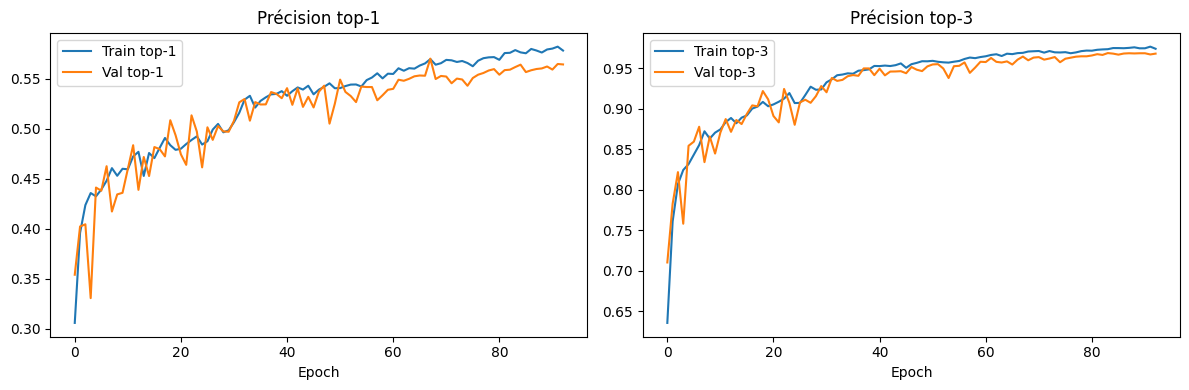

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Dossier Google Drive où enregistrer tous les artefacts du modèle
PROJECT_DIR = "/content/gdrive/MyDrive/TF_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Exports enregistrés dans: {PROJECT_DIR}")

# ══════════════════════════════════════════════════════════════════════════════
# WHY 9 CLASSES INSTEAD OF 13
# ──────────────────────────────────────────────────────────────────────────────
# From only pressure / temperature / humidity, some pairs are PHYSICALLY
# INDISTINGUISHABLE:
#   • "Pluie" vs "Averses"          → same T, P, H profile (only pattern differs)
#   • "Neige" vs "Neige légère"     → same T, H signature
#   • "Orage" vs "Orage violent"    → need rainfall rate data
#
# Merging them into 9 coherent classes removes noise from the labels and
# lets the model focus on what it can actually learn.
# ══════════════════════════════════════════════════════════════════════════════

CLASSES_FR = [
    "Clair / ensoleillé",             # 0
    "Peu / partiellement nuageux",    # 1  (merged 1+2)
    "Nuageux / couvert",              # 2
    "Brouillard / brume",             # 3
    "Précipitations liquides",        # 4  (rain + showers merged)
    "Précipitations neigeuses",       # 5  (snow + light snow merged)
    "Pluie et neige mêlées",          # 6
    "Orage",                          # 7  (storm + violent storm merged)
    "Vent fort",                      # 8
]
NUM_CLASSES = len(CLASSES_FR)

# History length (number of previous readings to include as features).
# Each reading adds 3 raw values + derived terms → significant information gain.
HISTORY_STEPS = 3  # t-1, t-2, t-3


# ── Remapping: old 13 classes → new 9 classes ─────────────────────────────────
_OLD_TO_NEW = {
    0: 0,   # Clair
    1: 1,   # Peu nuageux
    2: 1,   # Partiellement nuageux  → 1
    3: 2,   # Nuageux
    4: 4,   # Pluie
    5: 4,   # Averses               → 4
    6: 5,   # Neige
    7: 5,   # Neige légère          → 5
    8: 6,   # Pluie et neige mêlées
    9: 7,   # Orage
    10: 3,  # Brouillard
    11: 8,  # Vent fort
    12: 7,  # Orage violent         → 7
}


def map_coco_to_class(coco_value, prcp_value, snow_value, wspd_value):
    """Map Meteostat COCO code + ancillary fields to one of the 9 new classes."""
    c = int(coco_value) if np.isfinite(coco_value) else -1
    p = 0.0 if not np.isfinite(prcp_value) else float(prcp_value)
    s = 0.0 if not np.isfinite(snow_value) else float(snow_value)
    w = 0.0 if not np.isfinite(wspd_value) else float(wspd_value)

    if w >= 35.0:
        old = 11
    elif c == 1:
        old = 0
    elif c == 2:
        old = 1
    elif c == 3:
        old = 2
    elif c in (5, 6):
        old = 10
    elif c in (7, 8, 9):
        old = 4  # rain (showers merged)
    elif c in (10, 11):
        old = 8
    elif c in (12, 13, 14):
        old = 6  # snow (light merged)
    elif c in (15, 16):
        old = 9
    elif c == 17:
        old = 12
    else:
        # Fallback from numeric fields
        if s >= 0.2 and p >= 0.2:
            old = 8
        elif s >= 0.2:
            old = 6
        elif p >= 0.5:
            old = 4
        elif p > 0.0:
            old = 4   # treat showers same as rain
        elif w >= 35.0:
            old = 11
        else:
            old = 3

    return _OLD_TO_NEW[old]


# ── Feature engineering ────────────────────────────────────────────────────────
def absolute_humidity(temp_c, rh_pct):
    """Magnus formula approximation [g/m³]."""
    es = 6.112 * np.exp(17.67 * temp_c / (temp_c + 243.5))
    return 2.165 * es * rh_pct / (273.15 + temp_c)


def build_features(pres_arr, temp_arr, rhum_arr, history_steps=3):
    """
    Build feature matrix including:
      • Current values + derived terms (dew point, abs. humidity)
      • Delta from previous step (t-1)
      • Raw values from t-1 … t-N (history_steps)
      • 3h pressure tendency proxy (t - t-3 if available)
    """
    n = len(pres_arr)
    p = pres_arr.astype(np.float32)
    t = temp_arr.astype(np.float32)
    h = rhum_arr.astype(np.float32)

    def _shift(arr, k):
        s = np.roll(arr, k)
        s[:k] = arr[0]
        return s

    dew  = t - (100.0 - h) / 5.0          # classic approximation
    absh = absolute_humidity(t, h)         # [g/m³]

    cols = [p, t, h, dew, absh]

    # Deltas (t – t-1) and raw historical steps
    for k in range(1, history_steps + 1):
        pk, tk, hk = _shift(p, k), _shift(t, k), _shift(h, k)
        cols += [pk, tk, hk,
                 p - pk, t - tk, h - hk]

    # 3-step pressure tendency (strong short-range predictor)
    p3 = _shift(p, 3)
    cols.append(p - p3)

    X = np.column_stack(cols).astype(np.float32)
    return X


# ══════════════════════════════════════════════════════════════════════════════
# ── 2.  Build X and y  (replace the block that was in your notebook) ──────────
# ══════════════════════════════════════════════════════════════════════════════
if snow is None:
    snow = np.zeros_like(prcp, dtype=np.float32)
if wspd is None:
    wspd = np.zeros_like(prcp, dtype=np.float32)
if coco is None:
    coco = np.full_like(prcp, np.nan, dtype=np.float32)

X_raw = build_features(pres, temp, rhum, history_steps=HISTORY_STEPS)

y_idx = np.array([
    map_coco_to_class(coco[i], prcp[i], snow[i], wspd[i])
    for i in range(len(prcp))
], dtype=np.int32)

# Remove rows with NaN
mask = ~np.isnan(X_raw).any(axis=1)
X_raw, y_idx = X_raw[mask], y_idx[mask]

print(f"Dataset size   : {len(X_raw)} échantillons")
print(f"Nb de features : {X_raw.shape[1]}")
print(f"Nb de classes  : {NUM_CLASSES}")
print("Répartition des classes:")
for i, name in enumerate(CLASSES_FR):
    count = int((y_idx == i).sum())
    if count > 0:
        print(f"  [{i}] {name:<35}: {count:>6}")


# ── 3.  Normalize with StandardScaler (zero-mean, unit-variance) ──────────────
#   Better than min-max for neural networks: handles outliers gracefully.
x_train_raw, x_test_raw, y_train_idx, y_test_idx = train_test_split(
    X_raw, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw).astype(np.float32)
x_test  = scaler.transform(x_test_raw).astype(np.float32)

# Save scaler params for STM32 deployment
scaler_mean = scaler.mean_.astype(np.float32)
scaler_std  = scaler.scale_.astype(np.float32)
print(f"\nScaler mean (first 5): {scaler_mean[:5]}")
print(f"Scaler std  (first 5): {scaler_std[:5]}")

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test  = tf.keras.utils.to_categorical(y_test_idx,  num_classes=NUM_CLASSES)


# ── 4.  Focal loss (much better than cross-entropy for imbalanced classes) ────
#   γ=2 concentrates learning on hard samples; α mirrors class weights.
def focal_loss(gamma=2.0, alpha=None):
    def _loss(y_true, y_pred):
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        ce = -y_true * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        fl = (1.0 - pt) ** gamma * ce
        if alpha is not None:
            alpha_t = tf.reduce_sum(y_true * alpha, axis=-1, keepdims=True)
            fl = alpha_t * fl
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
    return _loss

# Compute per-class alpha from training distribution
class_counts = np.bincount(y_train_idx, minlength=NUM_CLASSES).astype(np.float32)
class_counts = np.where(class_counts == 0, 1, class_counts)
alpha_vals   = (1.0 / class_counts) / (1.0 / class_counts).sum()
alpha_tensor = tf.constant(alpha_vals * NUM_CLASSES, dtype=tf.float32)  # scale to ≈ 1


# ── 5.  Residual block helper ─────────────────────────────────────────────────
def residual_block(x, units, dropout_rate=0.05):
    shortcut = x
    x = layers.Dense(units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(units)(x)
    x = layers.BatchNormalization()(x)
    # Project shortcut if needed
    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units)(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


# ── 6.  Build model ───────────────────────────────────────────────────────────
num_features = x_train.shape[1]
inputs = layers.Input(shape=(num_features,))

# Gaussian noise as data augmentation (only active during training)
x = layers.GaussianNoise(0.02)(inputs)

# Entry projection
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)

# Residual blocks
x = residual_block(x, 128, dropout_rate=0.06)
x = residual_block(x, 96,  dropout_rate=0.05)
x = residual_block(x, 64,  dropout_rate=0.04)

# Head
x = layers.Dense(32, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.03)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


# ── 7.  Compile ───────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss=focal_loss(gamma=2.0, alpha=alpha_tensor),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    ],
)


# ── 8.  Datasets ──────────────────────────────────────────────────────────────
batch_size = 64
train_dataset = (tf.data.Dataset
    .from_tensor_slices((x_train, y_train))
    .shuffle(5000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE))
test_dataset = (tf.data.Dataset
    .from_tensor_slices((x_test, y_test))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE))


# ── 9.  Callbacks ─────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(PROJECT_DIR, "best_meteo_v2.keras"),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=25,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=8,
        min_lr=5e-6,
        verbose=1,
    ),
]


# ── 10.  Train ────────────────────────────────────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=150,
    validation_data=test_dataset,
    callbacks=callbacks,
    verbose=1,
)

best_epoch   = int(np.argmax(history.history["val_accuracy"])) + 1
best_val_acc = float(np.max(history.history["val_accuracy"]))
print(f"Meilleure val_accuracy: {best_val_acc:.4f} (epoch {best_epoch})")


# ── 11.  Evaluate ─────────────────────────────────────────────────────────────
test_loss, test_acc, test_top3 = model.evaluate(x_test, y_test, verbose=0)
print(f"\nPrécision test (top-1): {test_acc:.4f}")
print(f"Précision test (top-3): {test_top3:.4f}")


# ── 12.  Per-class breakdown ──────────────────────────────────────────────────
y_pred_idx = np.argmax(model.predict(x_test, verbose=0), axis=1)
print("\nRécapitulatif par classe:")
print(f"{'Classe':<35} {'Rappel':>7} {'Effectif':>9}")
print("-" * 55)
for i, name in enumerate(CLASSES_FR):
    mask_cls = y_test_idx == i
    if mask_cls.sum() == 0:
        continue
    recall = (y_pred_idx[mask_cls] == i).mean()
    print(f"{name:<35} {recall:>7.1%} {mask_cls.sum():>9}")


# ── 13.  Save model ───────────────────────────────────────────────────────────
model_path = os.path.join(PROJECT_DIR, f"meteo_v2_acc{test_acc:.4f}.keras")
model.save(model_path)
print(f"\nModèle sauvegardé: {model_path}")


# ── 14.  Export TFLite ────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Optional: quantize to int8 for smaller STM32 footprint (comment out if accuracy drops)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path  = os.path.join(PROJECT_DIR, "meteo_v2.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"Taille TFLite: {len(tflite_model) / 1024:.1f} KB")
print(f"Fichier TFLite sauvegardé: {tflite_path}")

# ── 15.  C header for STM32 deployment ───────────────────────────────────────
# Copy these constants into your STM32 pre-processing code.
print("\n/* ── scaler_params.h ───────────────────────────────── */")
print(f"#define N_FEATURES {num_features}")
print(f"static const float SCALER_MEAN[{num_features}] = {{")
print("    " + ", ".join(f"{v:.6f}f" for v in scaler_mean))
print("};")
print(f"static const float SCALER_STD[{num_features}] = {{")
print("    " + ", ".join(f"{v:.6f}f" for v in scaler_std))
print("};")
print(f"static const char* CLASSES_FR[{NUM_CLASSES}] = {{")
for name in CLASSES_FR:
    print(f'    "{name}",')
print("};")
print("/* ─────────────────────────────────────────────────── */\n")


# ── 16.  Predict helper ───────────────────────────────────────────────────────
def predict_meteo_fr(pressure, temperature, humidity,
                     history=None):
    """
    history: list of (pressure, temperature, humidity) for t-1, t-2, t-3
             If None, repeats current reading (cold start).
    """
    if history is None:
        history = [(pressure, temperature, humidity)] * HISTORY_STEPS

    def _shift_vals(k):
        idx = min(k - 1, len(history) - 1)
        return history[idx]

    p, t, h = pressure, temperature, humidity
    dew  = t - (100.0 - h) / 5.0
    absh = float(absolute_humidity(np.array([t]), np.array([h]))[0])

    cols = [p, t, h, dew, absh]
    for k in range(1, HISTORY_STEPS + 1):
        pk, tk, hk = _shift_vals(k)
        cols += [pk, tk, hk, p - pk, t - tk, h - hk]
    p3 = _shift_vals(3)[0]
    cols.append(p - p3)

    sample      = np.array(cols, dtype=np.float32).reshape(1, -1)
    sample_norm = (sample - scaler_mean) / scaler_std
    probs       = model.predict(sample_norm, verbose=0)[0]
    class_idx   = int(np.argmax(probs))

    print("Prévision météo:")
    print(f"  Classe prédite : {CLASSES_FR[class_idx]}")
    print(f"  Confiance      : {probs[class_idx]:.1%}")
    print("  Top 3:")
    for idx in np.argsort(probs)[-3:][::-1]:
        print(f"    [{idx}] {CLASSES_FR[idx]}: {probs[idx]:.1%}")
    return class_idx, probs

# Usage examples
predict_meteo_fr(1015, 22, 35)
predict_meteo_fr(1006,  9, 90, history=[(1008, 10, 86), (1009, 11, 83), (1010, 11, 80)])
predict_meteo_fr(1001, -1, 92, history=[(1003,  0, 88), (1005,  1, 85), (1007,  2, 82)])


# ── 17.  Training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"],     label="Train top-1")
axes[0].plot(history.history["val_accuracy"], label="Val top-1")
axes[0].set_title("Précision top-1")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["top3_accuracy"],     label="Train top-3")
axes[1].plot(history.history["val_top3_accuracy"], label="Val top-3")
axes[1].set_title("Précision top-3")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "training_curves_v2.png"), dpi=150)
plt.show()

In [ ]:
# Validation rapide du modèle TFLite exporté
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape :", input_details[0]['shape'])   # attendu: [1, 10]
print("Input dtype :", input_details[0]['dtype'])   # attendu: float32
print("Output shape:", output_details[0]['shape'])  # attendu: [1, 13]
print("Model multiclasse 3 capteurs (+ t-1) valide ✅")

Input shape : [1 3]
Input dtype : <class 'numpy.float32'>
Output shape: [1 1]
Model is valid ✅


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
